In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path("/teamspace/studios/this_studio/spotter-freight-rate")
DATA_DIR = PROJECT_ROOT / "data"

# Data paths
TRAIN_PATH = DATA_DIR / "train-test.csv"
VALIDATION_PATH = DATA_DIR / "validation.csv"
TEMPLATE_PATH = DATA_DIR / "validation-predictions-template.csv"
DECEMBER_PATH = DATA_DIR / "december-chart-inputs.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /teamspace/studios/this_studio/spotter-freight-rate
Data directory: /teamspace/studios/this_studio/spotter-freight-rate/data


In [2]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
template_df = pd.read_csv(TEMPLATE_PATH)
december_df = pd.read_csv(DECEMBER_PATH)

print("train_test.csv:", train_df.shape)
print("validation.csv:", validation_df.shape)
print("template:", template_df.shape)
print("December:", december_df.shape)

train_test.csv: (48000, 14)
validation.csv: (12000, 13)
template: (12000, 2)
December: (31, 7)


In [3]:
print("TRAIN COLUMNS")
print(train_df.columns.tolist())

print("\nVALIDATION COLUMNS")
print(validation_df.columns.tolist())

print("\nTEMPLATE COLUMNS")
print(template_df.columns.tolist())

print("\nDECEMBER COLUMNS")
print(december_df.columns.tolist())

TRAIN COLUMNS
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

VALIDATION COLUMNS
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

TEMPLATE COLUMNS
['load_id', 'predicted_rate']

DECEMBER COLUMNS
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [4]:
display(train_df.head())

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
display(validation_df.head())

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [6]:
display(template_df.head())

,load_id,predicted_rate
0,TE-000001,NaN
1,TE-000002,NaN
2,TE-000003,NaN
3,TE-000004,NaN
4,TE-000005,NaN


In [7]:
display(december_df.head())

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


In [8]:
print("target column present in train:", "posted_rate" in train_df.columns)
print("target column present in validation:", "posted_rate" in validation_df.columns)

target column present in train: True
target column present in validation: False


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [10]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  object 
 1   pickup        12000 non-null  object 
 2   delivery      12000 non-null  object 
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  object 
 9   weight        11835 non-null  float64
 10  date          12000 non-null  object 
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.2+ MB


In [11]:
# missing value analysis
missing_train = (
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_train["missing_pct"] = (
    100 * missing_train["missing_count"] / len(train_df)
)

display(missing_train)

,missing_count,missing_pct
market_index,374,0.779167
weight,300,0.625000
delivery,0,0.000000
pickup_lat,0,0.000000
load_id,0,0.000000
pickup,0,0.000000
delivery_lat,0,0.000000
pickup_lon,0,0.000000
distance,0,0.000000
delivery_lon,0,0.000000


In [12]:
missing_validation = (
    validation_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_validation["missing_pct"] = (
    100 * missing_validation["missing_count"] / len(validation_df)
)

display(missing_validation)

,missing_count,missing_pct
market_index,249,2.075
weight,165,1.375
delivery,0,0.000
pickup,0,0.000
load_id,0,0.000
pickup_lon,0,0.000
pickup_lat,0,0.000
delivery_lat,0,0.000
delivery_lon,0,0.000
equipment,0,0.000


In [13]:
# duplicate data if present
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in validation:", validation_df.duplicated().sum())

print(
    "Duplicate load_ids in train:",
    train_df["load_id"].duplicated().sum()
)

print(
    "Duplicate load_ids in validation:",
    validation_df["load_id"].duplicated().sum()
)

Duplicate rows in train: 0
Duplicate rows in validation: 0
Duplicate load_ids in train: 0
Duplicate load_ids in validation: 0


In [14]:
#understanding data range
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in validation:", validation_df.duplicated().sum())

print(
    "Duplicate load_ids in train:",
    train_df["load_id"].duplicated().sum()
)

print(
    "Duplicate load_ids in validation:",
    validation_df["load_id"].duplicated().sum()
)

Duplicate rows in train: 0
Duplicate rows in validation: 0
Duplicate load_ids in train: 0
Duplicate load_ids in validation: 0


In [15]:
# categorical variables
categorical_columns = [
    "pickup",
    "delivery",
    "equipment",
]

for col in categorical_columns:
    print(f"\n===== {col} =====")
    print("Unique values:", train_df[col].nunique())
    print(train_df[col].value_counts().head(15))


===== pickup =====
Unique values: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
Name: count, dtype: int64

===== delivery =====
Unique values: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Name: count, dtype: int64

===== equipment =====
Unique values: 3
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [16]:
#numerical summary
numeric_columns = train_df.select_dtypes(include=np.number).columns.tolist()

display(
    train_df[numeric_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [17]:
# investigating weights for training
print("Missing weight:", train_df["weight"].isna().sum())

print("Negative weights:", (train_df["weight"] < 0).sum())

print("Zero weights:", (train_df["weight"] == 0).sum())

print("\nMinimum weight:", train_df["weight"].min())
print("Maximum weight:", train_df["weight"].max())

Missing weight: 300
Negative weights: 292
Zero weights: 0

Minimum weight: -47500.0
Maximum weight: 47500.0


In [18]:
# weights for testing in validation csv
print("\nVALIDATION")
print("Missing weight:", validation_df["weight"].isna().sum())
print("Negative weights:", (validation_df["weight"] < 0).sum())
print("Zero weights:", (validation_df["weight"] == 0).sum())


VALIDATION
Missing weight: 165
Negative weights: 145
Zero weights: 0


In [19]:
print(train_df["posted_rate"].describe())

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


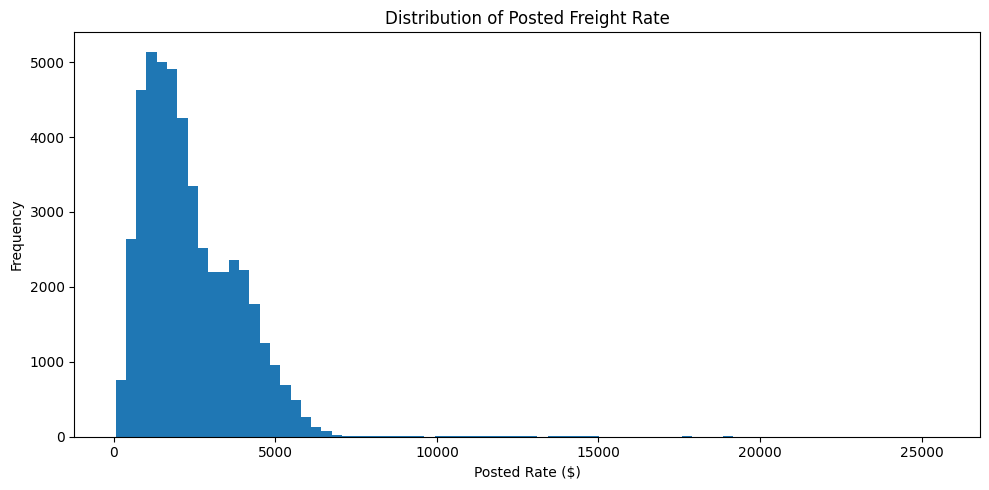

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["posted_rate"],
    bins=80
)

plt.xlabel("Posted Rate ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Posted Freight Rate")

plt.tight_layout()
plt.show()

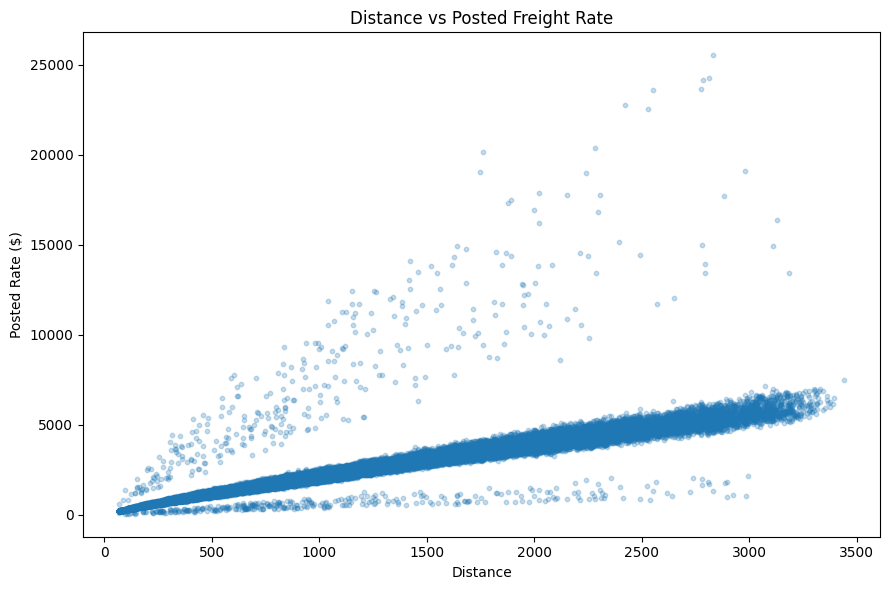

In [21]:
plt.figure(figsize=(9, 6))

plt.scatter(
    train_df["distance"],
    train_df["posted_rate"],
    alpha=0.25,
    s=10
)

plt.xlabel("Distance")
plt.ylabel("Posted Rate ($)")
plt.title("Distance vs Posted Freight Rate")

plt.tight_layout()
plt.show()

In [22]:
equipment_summary = (
    train_df
    .groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(equipment_summary)

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


In [34]:
train_df["date"] = pd.to_datetime(train_df["date"], errors="coerce")
validation_df["date"] = pd.to_datetime(validation_df["date"], errors="coerce")
december_df["date"] = pd.to_datetime(december_df["date"], errors="coerce")

# Check the types
print("Train date type:", train_df["date"].dtype)
print("Validation date type:", validation_df["date"].dtype)
print("December date type:", december_df["date"].dtype)

# Check whether conversion created invalid dates
print("\nInvalid train dates:", train_df["date"].isna().sum())
print("Invalid validation dates:", validation_df["date"].isna().sum())
print("Invalid December dates:", december_df["date"].isna().sum())

Train date type: datetime64[ns]
Validation date type: datetime64[ns]
December date type: datetime64[ns]

Invalid train dates: 0
Invalid validation dates: 0
Invalid December dates: 0


In [35]:
#rate over time
monthly_rate = (
    train_df
    .assign(month=train_df["date"].dt.to_period("M"))
    .groupby("month")["posted_rate"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
display(monthly_rate)

,month,count,mean,median
0,2025-01,4918,2255.967048,1915.200
1,2025-02,4337,2273.804801,1994.250
2,2025-03,5036,2372.268092,2022.920
3,2025-04,4819,2372.162308,2044.240
4,2025-05,4913,2421.776342,2065.510
5,2025-06,4783,2497.030115,2120.220
6,2025-07,4912,2415.162030,2059.145
7,2025-08,4759,2338.407661,2015.730
8,2025-09,4670,2406.374013,2057.130
9,2025-10,4853,2379.051374,2035.900


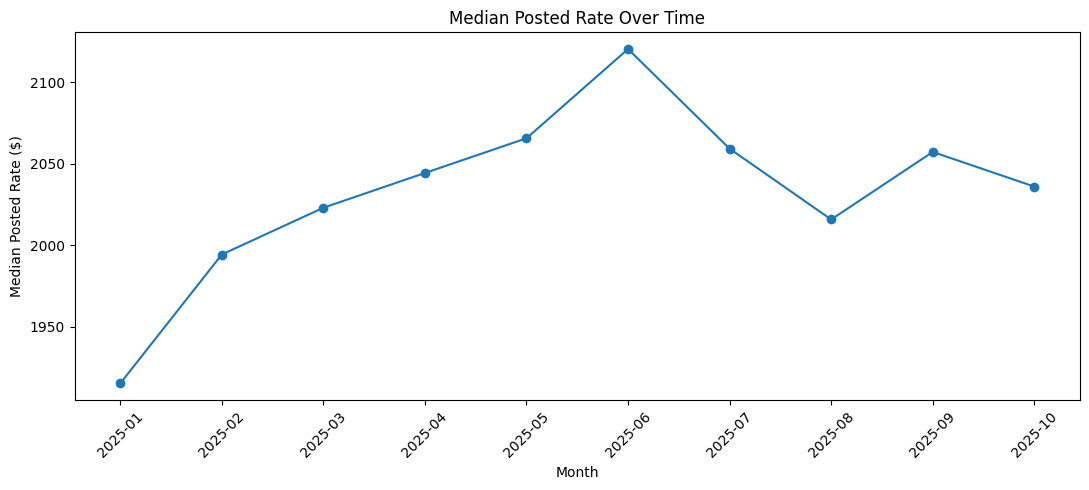

In [26]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_rate["month"].astype(str),
    monthly_rate["median"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Median Posted Rate ($)")
plt.title("Median Posted Rate Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
comparison = pd.DataFrame({
    "train_mean": train_df[
        ["distance", "weight", "market_index", "quote_signal"]
    ].mean(),

    "validation_mean": validation_df[
        ["distance", "weight", "market_index", "quote_signal"]
    ].mean(),
})

display(comparison)

,train_mean,validation_mean
distance,1135.856654,1141.773100
weight,31028.844004,30506.636248
market_index,1.083387,0.926913
quote_signal,2.062468,2.051334


In [28]:
comparison_median = pd.DataFrame({
    "train_median": train_df[
        ["distance", "weight", "market_index", "quote_signal"]
    ].median(),

    "validation_median": validation_df[
        ["distance", "weight", "market_index", "quote_signal"]
    ].median(),
})

display(comparison_median)

,train_median,validation_median
distance,953.30000,953.60000
weight,31436.50000,31193.00000
market_index,1.05580,0.92290
quote_signal,2.05575,2.05123


In [29]:
print("Validation rows:", len(validation_df))
print("Template rows:", len(template_df))

print(
    "Same IDs:",
    set(validation_df["load_id"]) == set(template_df["load_id"])
)

Validation rows: 12000
Template rows: 12000
Same IDs: True


In [30]:
print("Template columns:", template_df.columns.tolist())

Template columns: ['load_id', 'predicted_rate']


In [31]:
display(december_df)

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,NaN
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,NaN
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,NaN
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,NaN
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,NaN


In [32]:
for col in december_df.columns:
    print(f"{col}:",december_df[col].nunique(),"unique values")

pickup: 1 unique values
delivery: 1 unique values
distance: 1 unique values
equipment: 1 unique values
weight: 1 unique values
date: 31 unique values
predicted_rate: 0 unique values


In [36]:
#final summary table
print(f"Development rows: {len(train_df):,}")
print(f"Development columns: {train_df.shape[1]}")

print(f"Final validation rows: {len(validation_df):,}")
print(f"Final validation columns: {validation_df.shape[1]}")

print(f"Prediction template rows: {len(template_df):,}")
print(f"December rows: {len(december_df):,}")

print( f"\nDevelopment period: " f"{train_df['date'].min().date()} → "f"{train_df['date'].max().date()}")
print( f"Final prediction period: "f"{validation_df['date'].min().date()} → "f"{validation_df['date'].max().date()}")
print(f"\nTarget: posted_rate")

print(f"Unique pickup locations: {train_df['pickup'].nunique()}")
print(f"Unique delivery locations: {train_df['delivery'].nunique()}")
print(f"Unique equipment types: {train_df['equipment'].nunique()}")

Development rows: 48,000
Development columns: 14
Final validation rows: 12,000
Final validation columns: 13
Prediction template rows: 12,000
December rows: 31

Development period: 2025-01-01 → 2025-10-31
Final prediction period: 2025-11-01 → 2025-12-31

Target: posted_rate
Unique pickup locations: 64
Unique delivery locations: 64
Unique equipment types: 3


In [37]:
print(f"Mean freight rate: ${train_df['posted_rate'].mean():,.2f}")
print(f"Median freight rate: ${train_df['posted_rate'].median():,.2f}")

Mean freight rate: $2,373.98
Median freight rate: $2,030.76
